
# Airbnb Price Prediction using Multiple Linear Regression (MLR)




In [401]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [402]:

df = pd.read_csv("AB_NYC_2019.csv")

df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [403]:
df.shape

(48895, 16)

In [404]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [405]:
df = df.copy()

df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].median()
)

# Drop last_review column
df = df.drop('last_review', axis=1)

# Drop very few missing rows for 'name' and 'host_name'
df = df.dropna(subset=['name', 'host_name'])

# Remove extreme price outliers
df = df[df['price'] < 500]

# Select the desired columns for the model
df = df[[
    'neighbourhood_group',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'price',
    'latitude',
    'longitude',
    'neighbourhood',
    'calculated_host_listings_count'
]]

df.head()

,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month,availability_365,price,latitude,longitude,neighbourhood,calculated_host_listings_count
0,Brooklyn,Private room,1,9,0.21,365,149,40.64749,-73.97237,Kensington,6
1,Manhattan,Entire home/apt,1,45,0.38,355,225,40.75362,-73.98377,Midtown,2
2,Manhattan,Private room,3,0,0.72,365,150,40.80902,-73.94190,Harlem,1
3,Brooklyn,Entire home/apt,1,270,4.64,194,89,40.68514,-73.95976,Clinton Hill,1
4,Manhattan,Entire home/apt,10,9,0.10,0,80,40.79851,-73.94399,East Harlem,1


###Exploratory Data Analysis





In [406]:

print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nPrice Statistics")
print(df['price'].describe())


Dataset Shape: (47623, 11)

Missing Values
neighbourhood_group               0
room_type                         0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
availability_365                  0
price                             0
latitude                          0
longitude                         0
neighbourhood                     0
calculated_host_listings_count    0
dtype: int64

Price Statistics
count    47623.000000
mean       130.056422
std         85.086962
min          0.000000
25%         68.000000
50%        100.000000
75%        170.000000
max        499.000000
Name: price, dtype: float64


In [407]:
(df['price'] <= 0).sum()

np.int64(11)

In [408]:
df = df[df['price'] > 0]

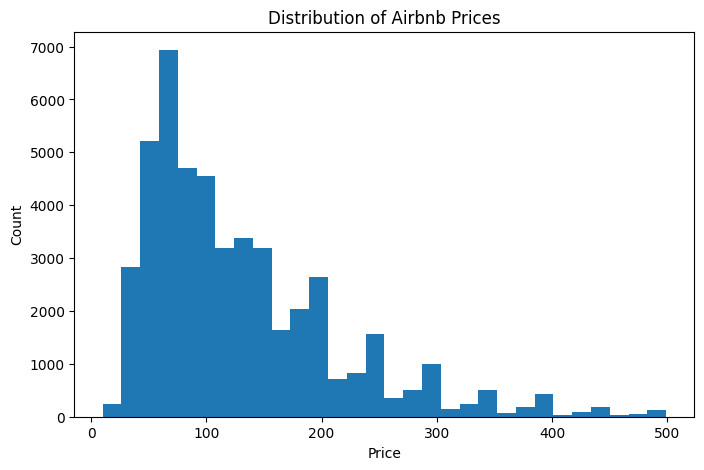

In [409]:

# Price distribution

plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=30)

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("Distribution of Airbnb Prices")

plt.show()


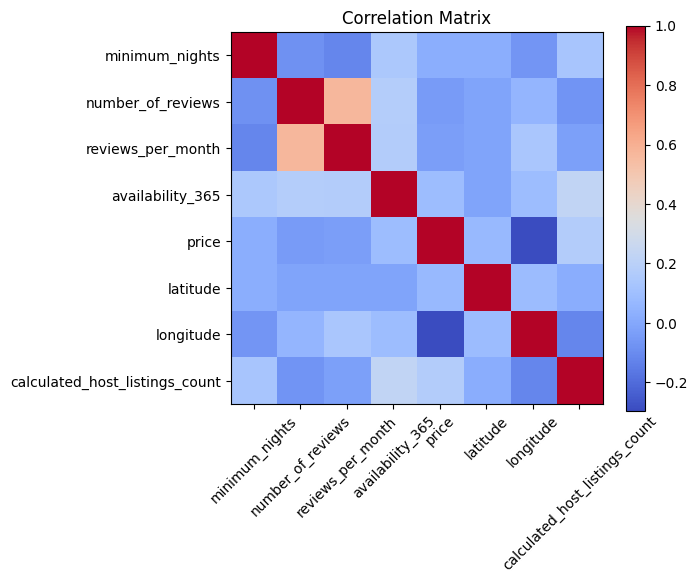

In [410]:

# Correlation matrix

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()


##  Features and Target

In [411]:
X = df[[
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'latitude',
    'longitude',
    'room_type',
    'neighbourhood_group',
    'neighbourhood',
    'calculated_host_listings_count'
]]

#feature encoding
X = pd.get_dummies(
    X,
    columns=[
        'room_type',
        'neighbourhood_group',
        'neighbourhood'
    ],
    drop_first=True
)

y = np.log(df['price'])

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (47612, 231)
Target Shape: (47612,)


In [412]:
q_low = df['price'].quantile(0.05)
q_high = df['price'].quantile(0.95)

df = df[
    (df['price'] >= q_low) &
    (df['price'] <= q_high)
]

## Train Test Split

In [413]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (38089, 231)
Testing Data: (9523, 231)


##Feature Scaling

In [414]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

##  Multiple Linear Regression Model

In [415]:

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


## Predictions

In [416]:

y_pred = model.predict(X_test)

# Convert log values back to normal prices
actual_prices = np.exp(y_test)
predicted_prices = np.exp(y_pred)

results = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

results.head(10)


,Actual Price,Predicted Price
0,80.0,57.081434
1,175.0,130.700905
2,69.0,68.289397
3,225.0,121.313923
4,225.0,170.057454
5,84.0,111.779909
6,100.0,101.829171
7,65.0,62.740551
8,250.0,229.772992
9,53.0,62.403088



## Model Evaluation

In [417]:

mae = mean_absolute_error(actual_prices, predicted_prices)

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

r2 = r2_score(actual_prices, predicted_prices)

print("Mean Absolute Error (MAE):", round(mae, 2))

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

print("R2 Score:", round(r2, 4))


Mean Absolute Error (MAE): 40.3
Root Mean Squared Error (RMSE): 63.33
R2 Score: 0.4407


##Actual vs Predicted Graph

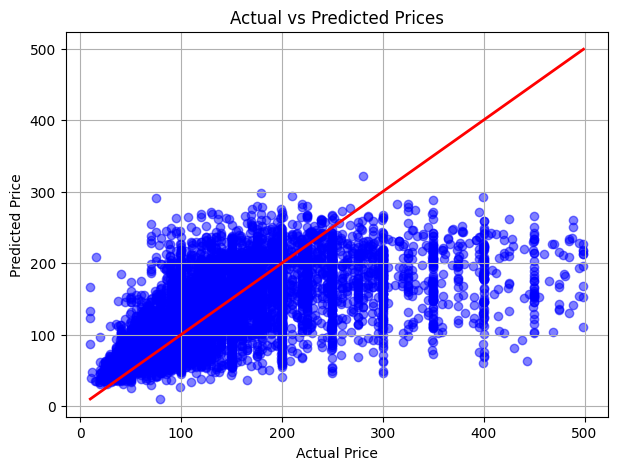

In [418]:

plt.figure(figsize=(7,5))

plt.scatter(
    actual_prices,
    predicted_prices,
    color='blue',
    alpha=0.5
)

plt.plot(
    [actual_prices.min(), actual_prices.max()],
    [actual_prices.min(), actual_prices.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.grid(True)

plt.show()


##  Residual Analysis

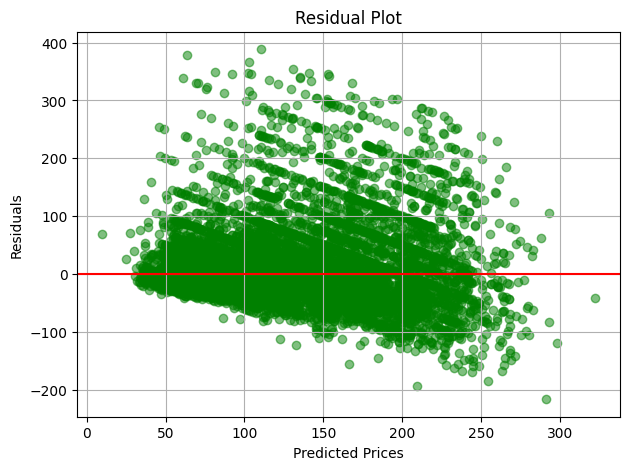

In [419]:

residuals = actual_prices - predicted_prices

plt.figure(figsize=(7,5))

plt.scatter(
    predicted_prices,
    residuals,
    color='green',
    alpha=0.5
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


## Using Random forest Model

In [420]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [421]:
r2 = r2_score(y_test, rf_pred)

print(r2)

actual_prices = np.exp(y_test)
predicted_prices = np.exp(rf_pred)

results = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

results

0.6358665732024854


,Actual Price,Predicted Price
0,80.0,53.900255
1,175.0,117.493558
2,69.0,50.955661
3,225.0,135.772897
4,225.0,202.872709
...,...,...
9518,251.0,218.801272
9519,150.0,122.785601
9520,40.0,58.163789
9521,71.0,98.258310



# Conclusion

- Multiple Linear Regression was successfully implemented.
- EDA and preprocessing improved the model.
- Log transformation reduced prediction errors.
- The model predicts Airbnb prices using multiple features.
- Residual analysis and feature importance were studied.
